## Mall Customers Clustering with KMeans, DBSCAN, & Agglomerative - Unsupervised Learning

> Tugas ini bertujuan untuk membangun model clustering pelanggan mall dengan KMeans, DBSCAN, dan Agglomerative. Dataset berasal dari sini : https://gist.githubusercontent.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf/raw/Mall_Customers.csv

> Referensi : https://colab.research.google.com/drive/1H1CGYKyAQ1mjy6vDAzhgeVctEOOeLPqC?usp=sharing


---

Nama lengkap : Aditya Nugraha Pratama Saiya

Asal universitas : Universitas Riau

---

### 1. Import module yang diperlukan

In [79]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [80]:
# 1. Import Library
import pandas as pd        # Manipulasi dan analisis data tabular
import numpy as np         # Operasi matematika dan array

import matplotlib.pyplot as plt  # Visualisasi data (grafik dasar)
import seaborn as sns            # Visualisasi data (grafik statistik)

from sklearn.preprocessing import StandardScaler            # Normalisasi/standarisasi fitur
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering  # Algoritma clustering
from sklearn.metrics import silhouette_score                # Evaluasi kualitas hasil clustering

### TODO #1 - Insight: Ciri-Ciri Dataset yang Cocok untuk Clustering

Dataset yang cocok untuk clustering memiliki ciri-ciri berikut:

#### 1. Tidak Memiliki Label/Target
Dataset tidak memiliki kolom jawaban yang sudah diketahui sebelumnya.
Tujuan clustering justru untuk **menemukan** pengelompokan dari data
yang belum berlabel — berbeda dengan supervised learning.

#### 2. Fitur Bersifat Numerik
Algoritma clustering bekerja berdasarkan **jarak antar data**, sehingga
fitur harus berupa angka. Fitur kategorikal (seperti Gender) perlu
dikonversi atau dihilangkan terlebih dahulu.

#### 3. Ada Pola Pengelompokan yang Tersembunyi
Data memiliki kemiripan atau pola tersembunyi yang bisa dikelompokkan,
misalnya pelanggan dengan income tinggi dan spending score tinggi
cenderung membentuk kelompok tersendiri.

#### 4. Tidak Ada Multikolinearitas Ekstrem
Fitur-fitur yang digunakan sebaiknya tidak terlalu saling berkorelasi
agar setiap fitur memberikan informasi yang unik dan bermakna
bagi proses clustering.

#### 5. Skala Fitur Perlu Dinormalisasi
Karena clustering berbasis jarak, fitur dengan skala besar akan
mendominasi. Oleh karena itu dataset perlu di-standarisasi
terlebih dahulu menggunakan `StandardScaler`.

#### Kesimpulan
Dataset Mall Customers memenuhi semua ciri di atas — tidak ada label,
fiturnya numerik (Age, Income, Spending Score), dan secara visual
terlihat ada pengelompokan alami antar pelanggan berdasarkan
kebiasaan belanja mereka.

### 2. Data collection

In [81]:
# 2. Load Dataset dari GitHub Gist
url = "https://gist.githubusercontent.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf/raw/Mall_Customers.csv"
df = pd.read_csv(url)

print(f'Jumlah data  : {df.shape[0]} baris')
print(f'Jumlah fitur : {df.shape[1]} kolom')
print(f'Kolom        : {list(df.columns)}')
print()

Jumlah data  : 200 baris
Jumlah fitur : 5 kolom
Kolom        : ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']



In [82]:
# Melihat 5 data pertama
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [83]:
# Melihat 5 data terakhir
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [84]:
# Informasi tipe data dan missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [85]:
# Statistik dasar setiap kolom
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [86]:
# Cek missing values per kolom
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### 3.  Data preprocessing

In [87]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### TODO #2 :

> Isi insight : Kenapa menggunakan fitur ini? Bagaimana yang lainnya? (CustomerID, Gender)

> Insight

### 4. KMeans Clustering (k=5)

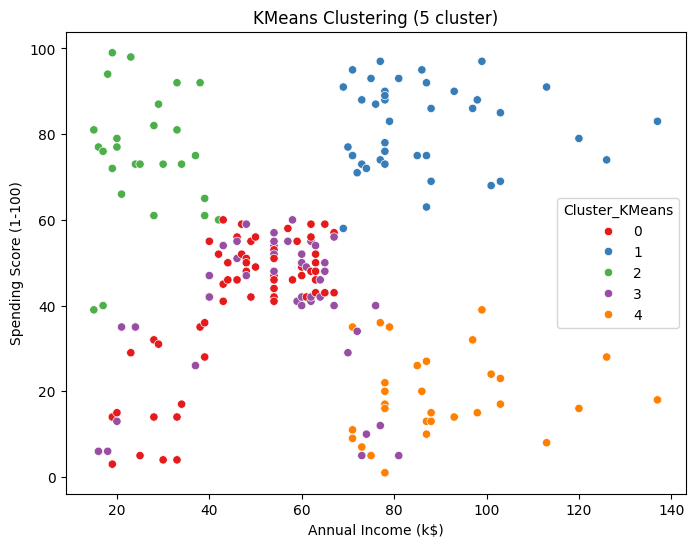



Silhouette Score KMeans: 0.40846873777345605


In [88]:
# KMeans Clustering (k=5)
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)
df['Cluster_KMeans'] = y_kmeans

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster_KMeans', palette='Set1')
plt.title("KMeans Clustering (5 cluster)")
plt.show()

print("\n\nSilhouette Score KMeans:", silhouette_score(X_scaled, y_kmeans))


### TODO #3 :

> Isi insight : Bagaimana cara kerja dari K-Means Clustering? Dan apa analisismu terhadap hasil diatas?

> Insight

### TODO #4 :

> Isi insight : Apa itu Silhouette Score?

> Insight

### 5. DBSCAN Clustering

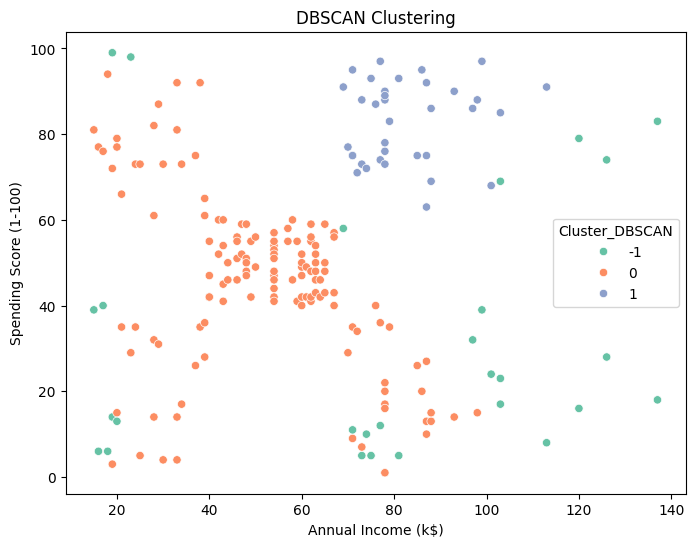



Silhouette Score DBSCAN: 0.18803828359177516


In [89]:
# DBSCAN Clustering
dbscan = DBSCAN(eps=0.6, min_samples=5)
y_dbscan = dbscan.fit_predict(X_scaled)
df['Cluster_DBSCAN'] = y_dbscan

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster_DBSCAN', palette='Set2')
plt.title("DBSCAN Clustering")
plt.show()

print("\n\nSilhouette Score DBSCAN:", silhouette_score(X_scaled, y_dbscan))


### TODO #5 :

> Isi insight : Bagaimana cara kerja dari DBSCAN Clustering? Dan apa analisismu terhadap hasil diatas?

> Insight

### 6. Agglomerative Clustering

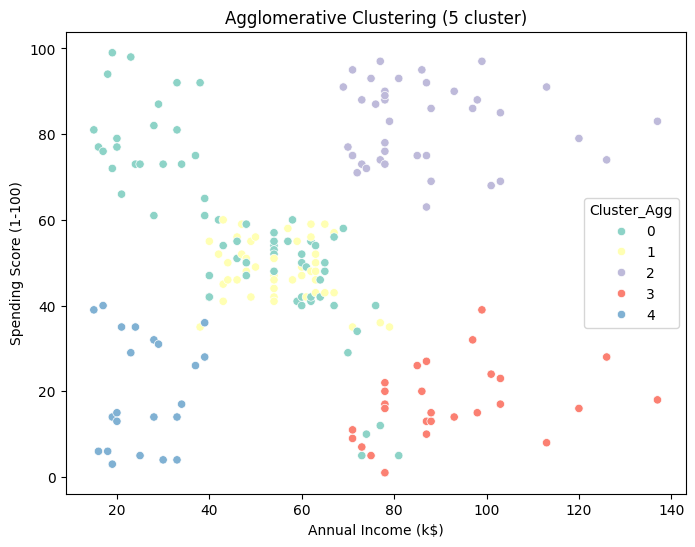



Silhouette Score Agglomerative: 0.39002826186267214


In [90]:
# Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=5)
y_agg = agg.fit_predict(X_scaled)
df['Cluster_Agg'] = y_agg

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster_Agg', palette='Set3')
plt.title("Agglomerative Clustering (5 cluster)")
plt.show()

print("\n\nSilhouette Score Agglomerative:", silhouette_score(X_scaled, y_agg))


### TODO #6 :

> Isi insight : Bagaimana cara kerja dari Agglomerative Clustering? Dan apa analisismu terhadap hasil diatas?

> Insight

### 7. Perbandingan

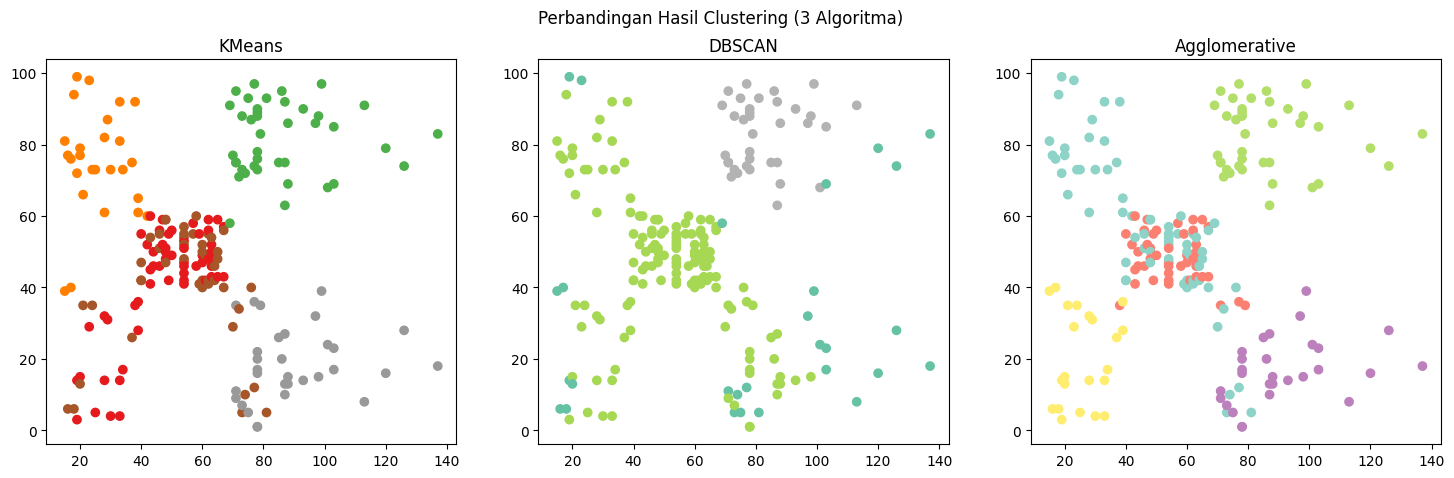

In [91]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster_KMeans'], cmap='Set1')
axs[0].set_title('KMeans')

axs[1].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster_DBSCAN'], cmap='Set2')
axs[1].set_title('DBSCAN')

axs[2].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster_Agg'], cmap='Set3')
axs[2].set_title('Agglomerative')

plt.suptitle("Perbandingan Hasil Clustering (3 Algoritma)")
plt.show()


## TODO #7 **Analisis Visual: Perbandingan Hasil Clustering (3 Algoritma)**

(Isi TODO dibawah)

### **1. KMeans**

TODO

---

### **2. DBSCAN**

TODO
---

### **3. Agglomerative Clustering**

TODO

---

## Kesimpulan Naratif

TODO

